TASK: MULTI-LINEAR REGRESSION - CAR PRICE PREDICTION
Dataset: Car Price Prediction Dataset (Kaggle - bhavikjikadara/car-price-prediction-dataset)
Goal: Identify which variables significantly predict the selling price of a car
      in the American market, and how well those variables explain the price.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm

In [ ]:
# ----------------------------------------------------------------------
# 1. LOAD DATASET
# ----------------------------------------------------------------------
import kagglehub

path_dataset = kagglehub.dataset_download("bhavikjikadara/car-price-prediction-dataset")
dataset_path = path_dataset + "/car_prediction_data.csv"

df = pd.read_csv(dataset_path)
print("Data loaded. Shape:", df.shape)
print(df.columns.tolist())

Data loaded. Shape: (301, 9)
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


In [5]:

# ----------------------------------------------------------------------
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ----------------------------------------------------------------------
print("\n--- Data Info ---")
print(df.info())

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

print("\n--- Summary Statistics ---")
print(df.describe())


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None

--- First 5 Rows ---
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  201

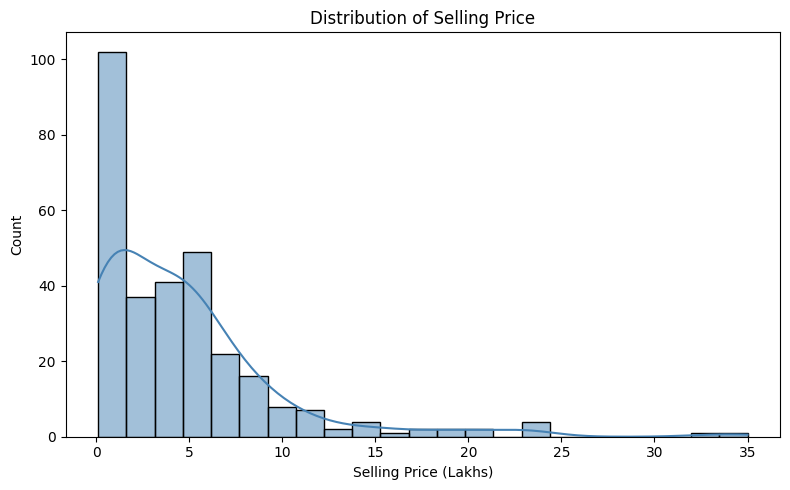

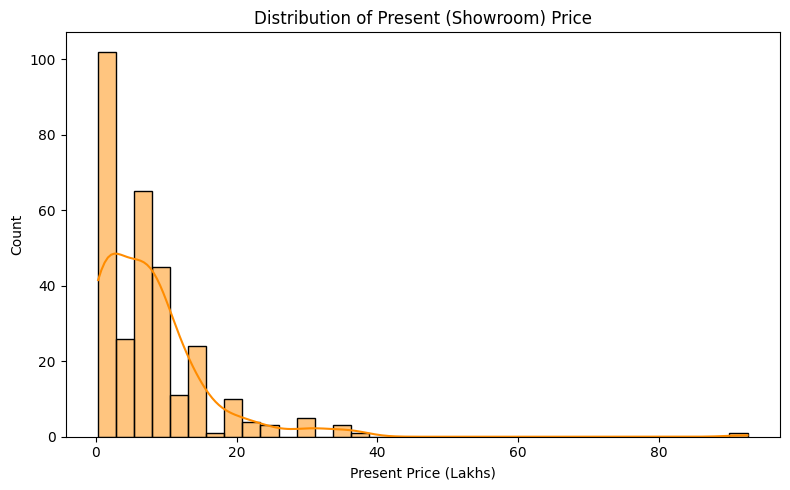

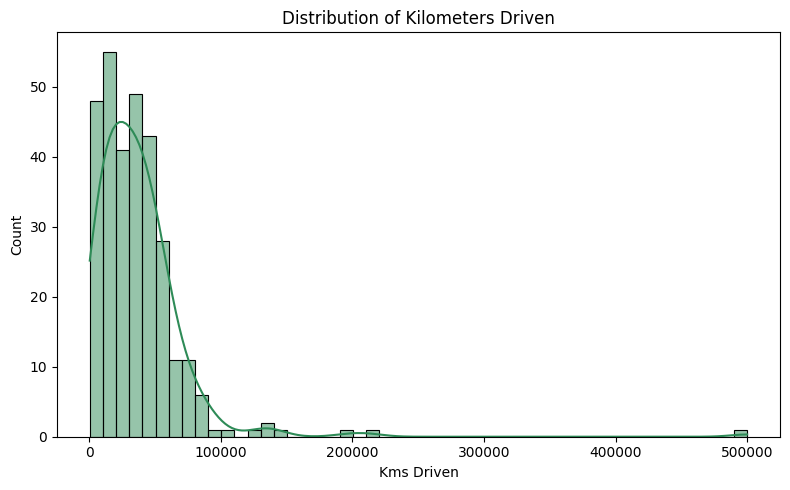

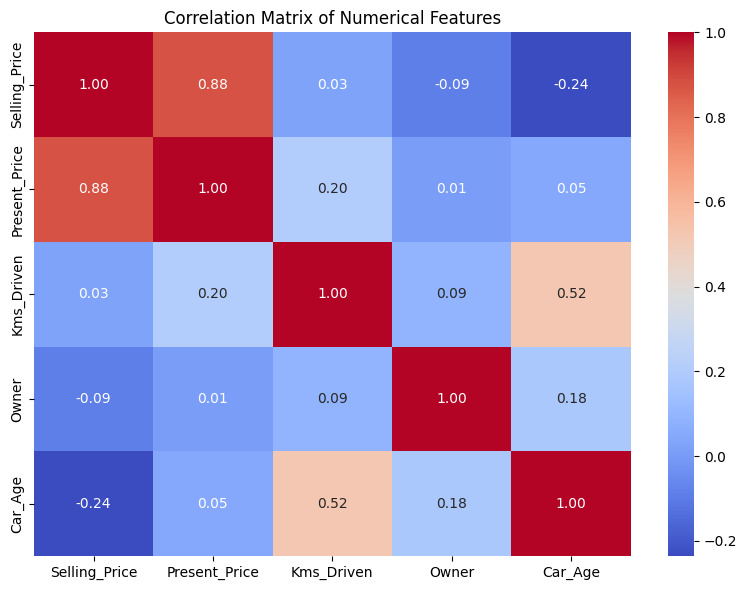


--- Correlation with Selling Price ---
Selling_Price    1.000000
Present_Price    0.878983
Kms_Driven       0.029187
Owner           -0.088344
Car_Age         -0.236141
Name: Selling_Price, dtype: float64


/tmp/ipykernel_1165/1460091519.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Selling_Price', data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_1165/1460091519.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Selling_Price', data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_1165/1460091519.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Selling_Price', data=df, ax=axes[i], palette='Set2')


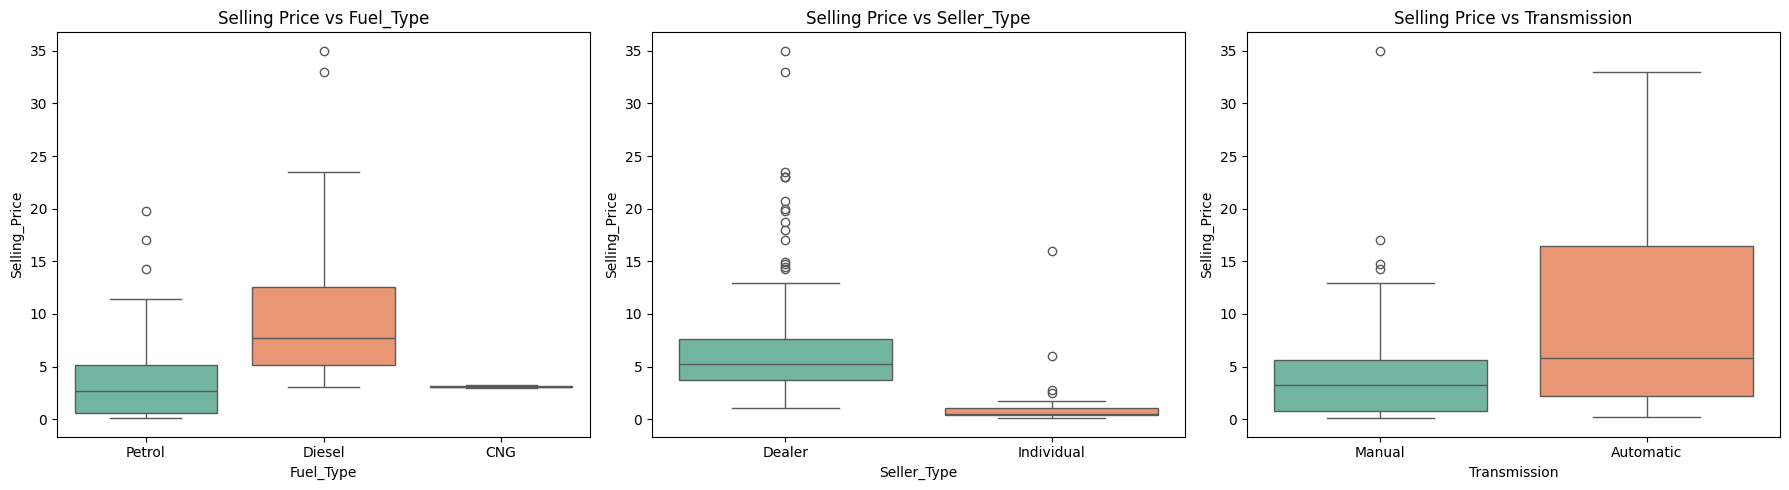

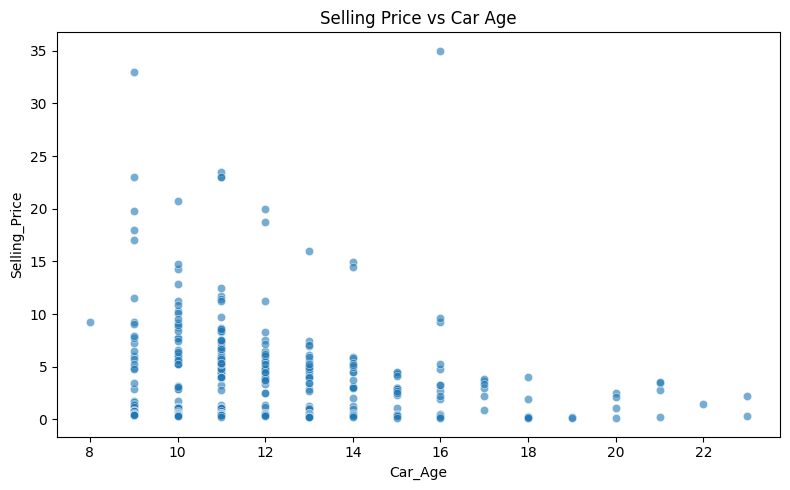

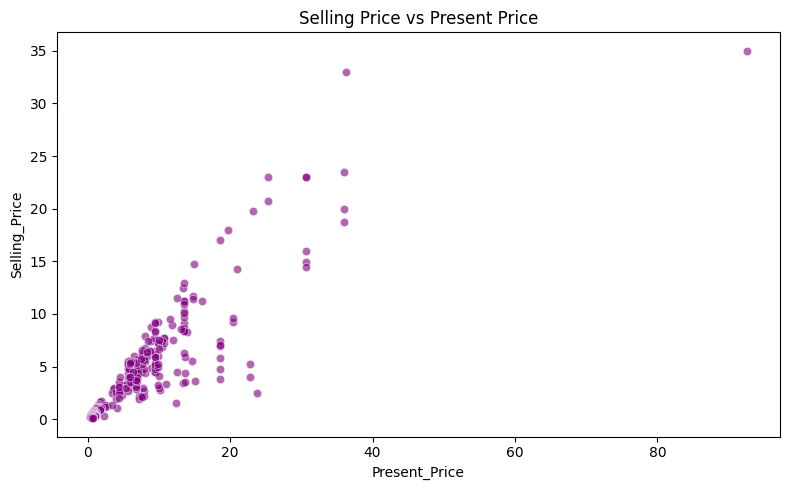

In [6]:
# Feature engineering: Car Age instead of raw Year (more interpretable)
df['Car_Age'] = 2026 - df['Year']

# a) Distribution of Selling Price
plt.figure(figsize=(8, 5))
sns.histplot(df['Selling_Price'], kde=True, color='steelblue')
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (Lakhs)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("plots/A_selling_price_distribution.png")
plt.show()

# b) Distribution of Present Price
plt.figure(figsize=(8, 5))
sns.histplot(df['Present_Price'], kde=True, color='darkorange')
plt.title('Distribution of Present (Showroom) Price')
plt.xlabel('Present Price (Lakhs)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("plots/A_present_price_distribution.png")
plt.show()

# c) Distribution of Kms Driven
plt.figure(figsize=(8, 5))
sns.histplot(df['Kms_Driven'], kde=True, color='seagreen')
plt.title('Distribution of Kilometers Driven')
plt.xlabel('Kms Driven')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("plots/A_kms_driven_distribution.png")
plt.show()

# d) Correlation heatmap of numerical features
plt.figure(figsize=(8, 6))
numeric_cols = ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Car_Age']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig("plots/A_correlation_heatmap.png")
plt.show()
print("\n--- Correlation with Selling Price ---")
print(corr['Selling_Price'].sort_values(ascending=False))

# e) Categorical variables vs Selling Price
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_cols):
    sns.boxplot(x=col, y='Selling_Price', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Selling Price vs {col}')
plt.tight_layout()
plt.savefig("plots/A_categorical_vs_price.png")
plt.show()

# f) Selling Price vs Car Age (scatter)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df, alpha=0.6)
plt.title('Selling Price vs Car Age')
plt.tight_layout()
plt.savefig("plots/A_price_vs_age.png")
plt.show()

# g) Selling Price vs Present Price (scatter)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df, alpha=0.6, color='purple')
plt.title('Selling Price vs Present Price')
plt.tight_layout()
plt.savefig("plots/A_price_vs_present_price.png")
plt.show()

In [8]:

# ----------------------------------------------------------------------
# 3. DATA PREPROCESSING
# ----------------------------------------------------------------------
# Drop duplicates
df_clean = df.drop_duplicates().copy()

# Drop identifier / redundant columns (Car_Name is high-cardinality text, Year replaced by Car_Age)
df_model = df_clean.drop(columns=['Car_Name', 'Year'])

# Separate features and target
X = df_model.drop(columns=['Selling_Price'])
y = df_model['Selling_Price']

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nPreprocessing complete. Features used:", list(X_encoded.columns))



Preprocessing complete. Features used: ['Present_Price', 'Kms_Driven', 'Owner', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual']


In [9]:

# ----------------------------------------------------------------------
# 4. MODEL - MULTIPLE LINEAR REGRESSION
# ----------------------------------------------------------------------

# 4a. Statsmodels OLS - to inspect p-values / statistical significance of each feature
X_train_sm = sm.add_constant(X_train.astype(float))
ols_model = sm.OLS(y_train, X_train_sm).fit()
print("\n================== STATSMODELS OLS SUMMARY ==================")
print(ols_model.summary())

# 4b. Scikit-learn Linear Regression - for prediction & evaluation
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\n================== FEATURE COEFFICIENTS (standardized) ==================")
print(coef_df)

# 5-fold cross validation for generalizability
cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"\nCross-Validation R^2 scores: {cv_scores}")
print(f"Cross-Validation R^2 (mean): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


================== STATSMODELS OLS SUMMARY ==================
                            OLS Regression Results                            
Dep. Variable:          Selling_Price   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     273.7
Date:                Tue, 01 Sep 2026   Prob (F-statistic):          5.81e-113
Time:                        03:05:57   Log-Likelihood:                -440.17
No. Observations:                 239   AIC:                             898.3
Df Residuals:                     230   BIC:                             929.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------


================== TEST SET PERFORMANCE METRICS ==================
R^2 Score                      : 0.7528
Mean Absolute Error (MAE)      : 1.4729 Lakhs
Root Mean Squared Error (RMSE) : 2.5240 Lakhs
Cross-Validation R^2 (mean)    : 0.8687 (+/- 0.0429)


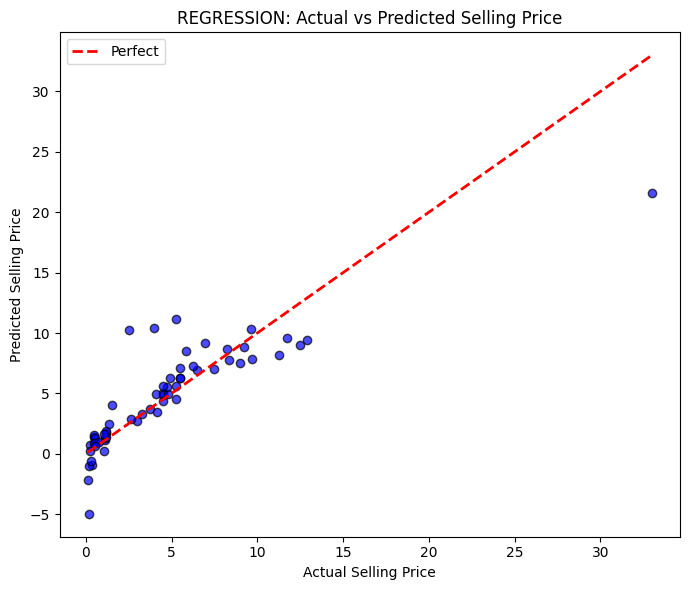

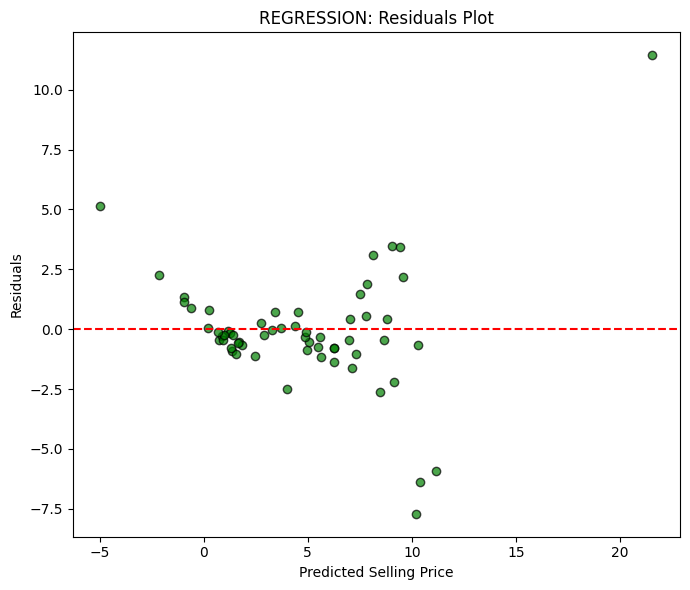

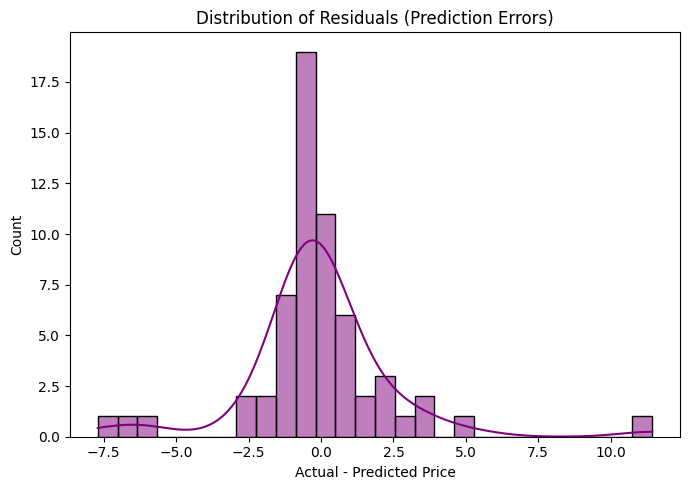


All plots saved in the 'plots/' folder.

================== SUMMARY ==================
Most significant predictors (by |coefficient| and OLS p-value < 0.05):
                  Feature  Coefficient
0           Present_Price     3.854765
3                 Car_Age    -0.951117
4        Fuel_Type_Diesel     0.836262
6  Seller_Type_Individual    -0.621313
7     Transmission_Manual    -0.528204


In [10]:

# ----------------------------------------------------------------------
# 5. MODEL EVALUATION
# ----------------------------------------------------------------------
y_pred = lr_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test = r2_score(y_test, y_pred)

print("\n================== TEST SET PERFORMANCE METRICS ==================")
print(f"R^2 Score                      : {r2_test:.4f}")
print(f"Mean Absolute Error (MAE)      : {mae:.4f} Lakhs")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f} Lakhs")
print(f"Cross-Validation R^2 (mean)    : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# a) Actual vs Predicted plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('REGRESSION: Actual vs Predicted Selling Price')
plt.legend()
plt.tight_layout()
plt.savefig("plots/A_actual_vs_predicted.png")
plt.show()

# b) Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residuals, alpha=0.7, color='green', edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Selling Price')
plt.ylabel('Residuals')
plt.title('REGRESSION: Residuals Plot')
plt.tight_layout()
plt.savefig("plots/A_residuals_plot.png")
plt.show()

# c) Residuals distribution
plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution of Residuals (Prediction Errors)')
plt.xlabel('Actual - Predicted Price')
plt.tight_layout()
plt.savefig("plots/A_residuals_distribution.png")
plt.show()

print("\nAll plots saved in the 'plots/' folder.")
print("\n================== SUMMARY ==================")
print("Most significant predictors (by |coefficient| and OLS p-value < 0.05):")
print(coef_df.head(5))